In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Balaji\AppData\Roaming\Python\Python312\Scripts\Diamond_Processed.csv")
df

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,0,0.23,Ideal,E,SI2,61.50,55.0,5.789960,3.95,3.98,2.43
1,1,0.21,Premium,E,SI1,59.80,61.0,5.789960,3.89,3.84,2.31
2,2,0.23,Good,E,VS1,58.75,63.5,5.793014,4.05,4.07,2.31
3,3,0.29,Premium,I,VS2,62.40,58.0,5.814131,4.20,4.23,2.63
4,4,0.31,Good,J,SI2,63.30,58.0,5.817111,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53770,53935,0.72,Ideal,D,SI1,60.80,57.0,7.922261,5.75,5.76,3.50
53771,53936,0.72,Good,D,SI1,63.10,55.0,7.922261,5.69,5.75,3.61
53772,53937,0.70,Very Good,D,SI1,62.80,60.0,7.922261,5.66,5.68,3.56
53773,53938,0.86,Premium,H,SI2,61.00,58.0,7.922261,6.15,6.12,3.74


EDA:

<Axes: xlabel='price', ylabel='Count'>

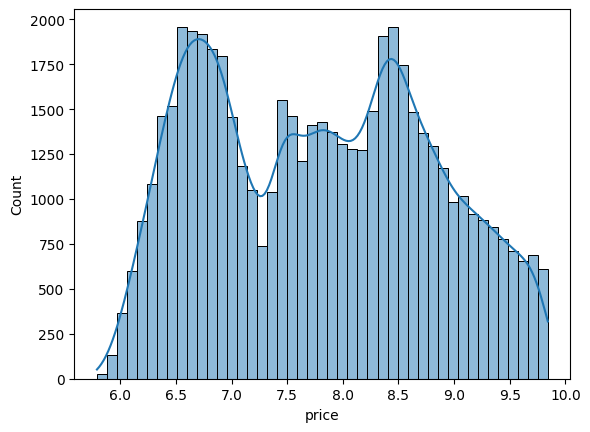

In [2]:
# 1. Price Distribution (After Log Transform)
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["price"], kde=True)

Insight: Most diamonds fall within the mid-price range, while premium diamonds form a smaller proportion of the market.

<Axes: xlabel='carat', ylabel='Count'>

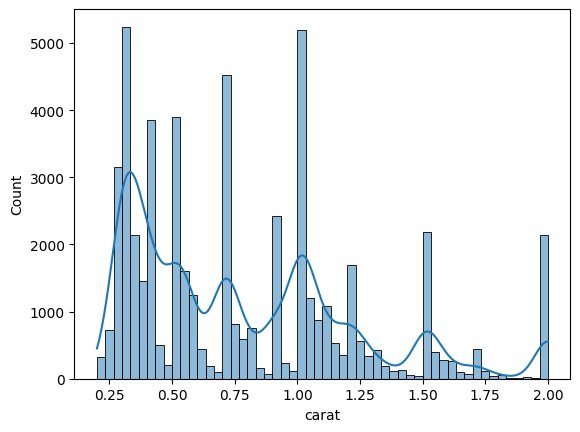

In [3]:
# 2. Carat Distribution
sns.histplot(df["carat"], kde=True)

Insight: Majority of diamonds have lower carat weights.

<Axes: xlabel='cut', ylabel='count'>

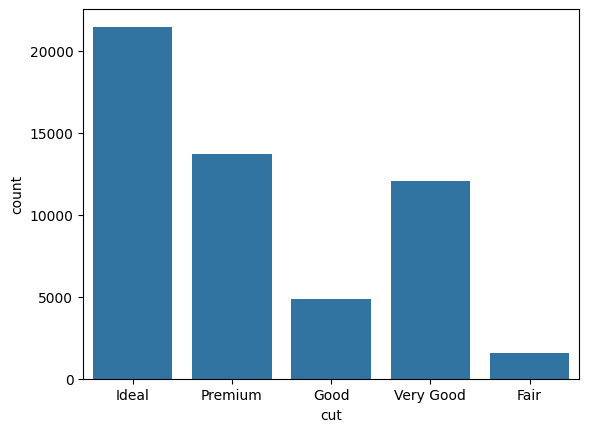

In [4]:
#3. Cut Quality Distribution:
sns.countplot(data=df,x="cut")

Insight: Ideal and Premium cuts dominate the dataset.

<Axes: xlabel='color', ylabel='count'>

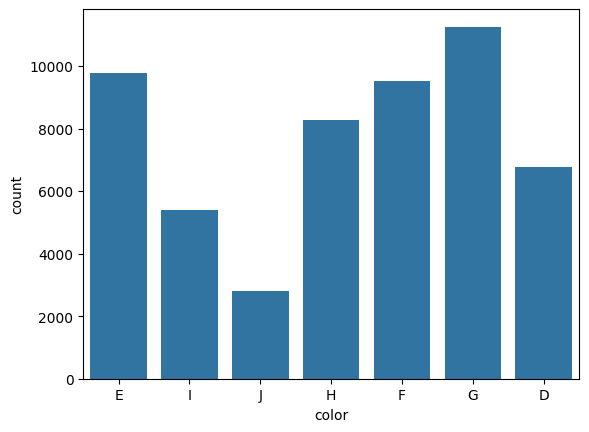

In [5]:
# 4. Color Grade Distribution:
sns.countplot(data=df,x="color")

Insight: Certain color grades occur more frequently in the inventory.

<Axes: xlabel='clarity', ylabel='count'>

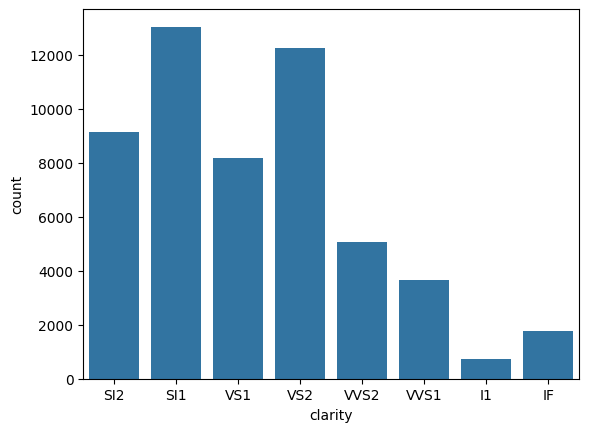

In [6]:
# 5. Clarity Distribution:
sns.countplot(data=df,x="clarity")

Insight: SI1 and VS2 categories are most common.

<Axes: xlabel='carat', ylabel='price'>

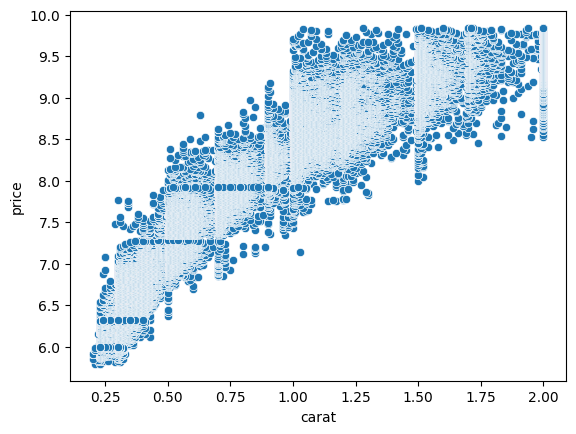

In [7]:
#6. Carat vs Price:
sns.scatterplot(data=df,x="carat",y="price")

Insight: Strong positive relationship between carat and price.

<Axes: xlabel='cut', ylabel='price'>

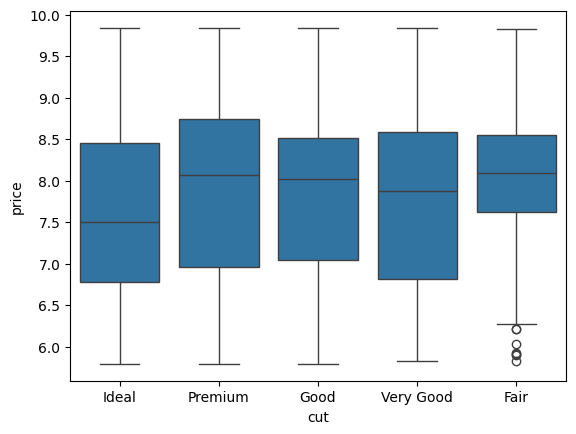

In [8]:
#7. Cut vs Price:
sns.boxplot(data=df,x="cut",y="price")

Insight: The Fair cut category contains a few low-priced diamonds that appear as boxplot outliers. Since these observations are valid business records and belong to a naturally lower-quality cut category, they were retained in the analysis.

<Axes: xlabel='color', ylabel='price'>

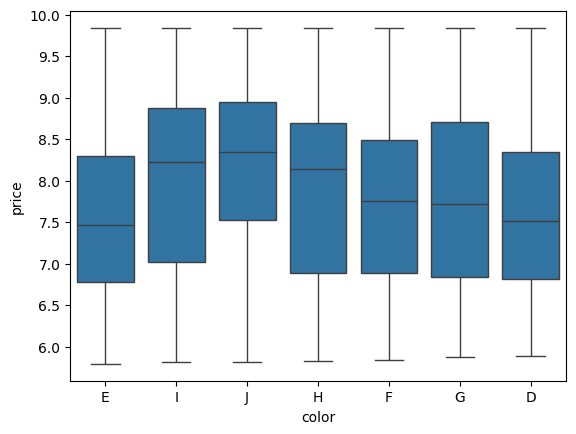

In [9]:
# 8. Color vs Price:
sns.boxplot(data=df,x="color",y="price")

Insight: Color grade influences pricing significantly.

<Axes: xlabel='clarity', ylabel='price'>

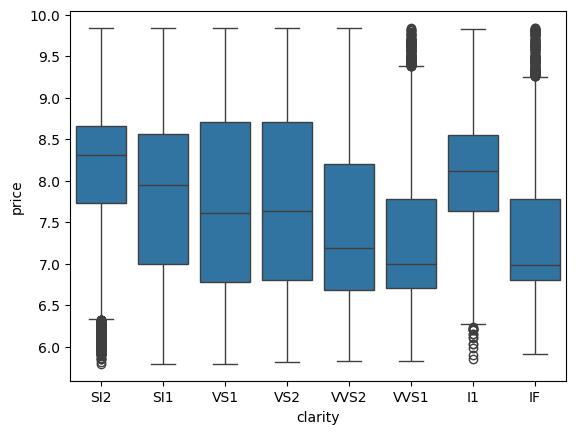

In [10]:
# 9. Clarity vs Price:
sns.boxplot(data=df,x="clarity",y="price")

Insight: Although some categories exhibit boxplot outliers, these observations represent valid premium and budget diamonds rather than anomalies. Therefore, they were retained. The analysis also indicates that clarity alone does not determine price, suggesting the influence of other attributes such as carat, color, and cut.

<Axes: >

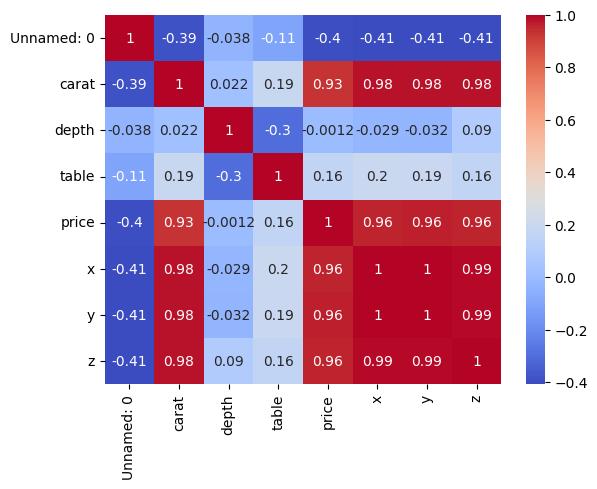

In [11]:
#10. Correlation Heatmap:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

Insight:Carat, x, y, and z show strong correlation with price.

Note: SKipping the feature engineering part. Doing Encoding,using RFE selecting the best features and if needed we will do the feature engineering.

In [12]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [13]:
# Encoding:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=[
        ['Fair','Good','Very Good','Premium','Ideal'],
        ['J','I','H','G','F','E','D'],
        ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']])

df[['cut','color','clarity']] = encoder.fit_transform(df[['cut','color','clarity']])


In [29]:
import joblib
joblib.dump(encoder, "diamond_encoder.pkl")

['diamond_encoder.pkl']

In [14]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4.0,5.0,1.0,61.50,55.0,5.789960,3.95,3.98,2.43
1,0.21,3.0,5.0,2.0,59.80,61.0,5.789960,3.89,3.84,2.31
2,0.23,1.0,5.0,4.0,58.75,63.5,5.793014,4.05,4.07,2.31
3,0.29,3.0,1.0,3.0,62.40,58.0,5.814131,4.20,4.23,2.63
4,0.31,1.0,0.0,1.0,63.30,58.0,5.817111,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53770,0.72,4.0,6.0,2.0,60.80,57.0,7.922261,5.75,5.76,3.50
53771,0.72,1.0,6.0,2.0,63.10,55.0,7.922261,5.69,5.75,3.61
53772,0.70,2.0,6.0,2.0,62.80,60.0,7.922261,5.66,5.68,3.56
53773,0.86,3.0,2.0,1.0,61.00,58.0,7.922261,6.15,6.12,3.74


R² Score : 0.992
   Feature  Importance
7        y    0.855088
0    carat    0.062056
6        x    0.031254
3  clarity    0.030054
2    color    0.015979
8        z    0.001999
4    depth    0.001366
1      cut    0.001138
5    table    0.001066


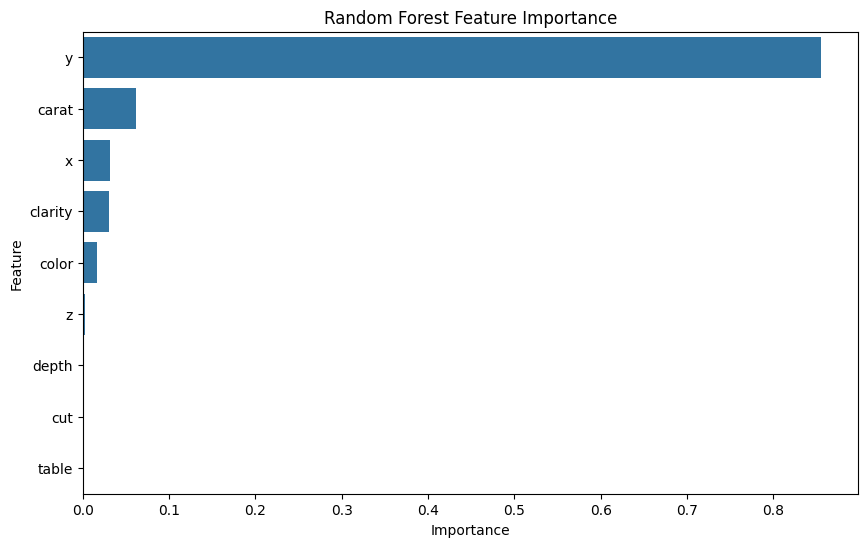

In [15]:
# Feature Selection using Random Forest Regressor:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df.drop("price",axis=1)
y = df["price"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=5)

rfr = RandomForestRegressor(random_state=5)
rfr.fit(X_train,y_train)
y_pred = rfr.predict(X_test)

r2 = r2_score(y_test,y_pred)

print(f"R² Score : {round(r2,4)}")

# Feature Importance:

importance_df = pd.DataFrame({"Feature":X.columns,"Importance":rfr.feature_importances_})
importance_df = importance_df.sort_values(by="Importance",ascending=False)
print(importance_df)

# Visualisation:

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df,x="Importance",y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

R² Score : 0.9906
   Feature  Importance
0        y    0.856892
1    carat    0.063737
2        x    0.032906
3  clarity    0.030224
4    color    0.016241


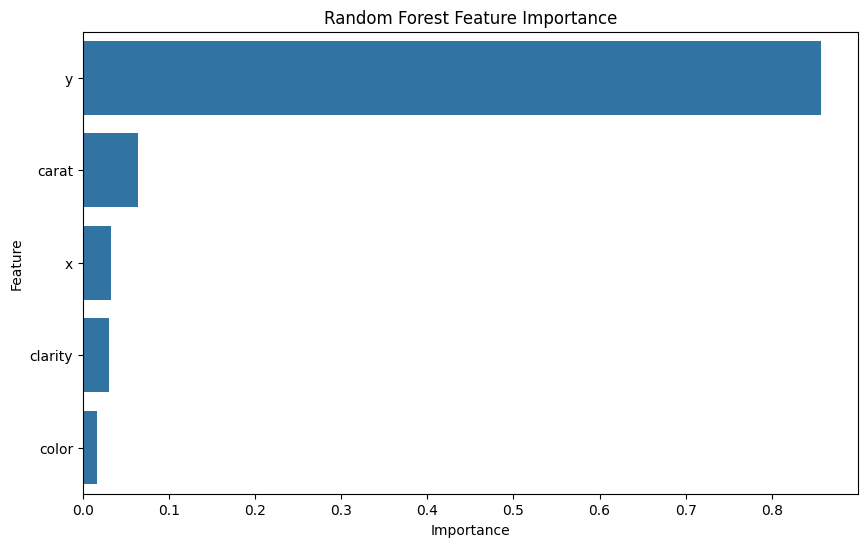

In [16]:
# Feature Selection using Random Forest Regressor:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df[['y','carat','x','clarity','color']]
y = df["price"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=5)

rfr = RandomForestRegressor(random_state=5)
rfr.fit(X_train,y_train)
y_pred = rfr.predict(X_test)

r2 = r2_score(y_test,y_pred)

print(f"R² Score : {round(r2,4)}")

# Feature Importance:

importance_df = pd.DataFrame({"Feature":X.columns,"Importance":rfr.feature_importances_})
importance_df = importance_df.sort_values(by="Importance",ascending=False)
print(importance_df)

# Visualisation:

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df,x="Importance",y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

Note: I used Random Forest Feature Importance to identify the most influential predictors. The top 5 features were y, carat, x, clarity and color. When I retrained the model using only these features, the R² score decreased from 0.9920 to 0.9906, a negligible reduction. Therefore, I retained the top 5 features as they provided almost the same predictive power with lower complexity. So skipping the feature Engineering part.

In [17]:
# Model Building:
from sklearn.model_selection import train_test_split

X = df[['y','carat','x','clarity','color']]
y = df['price']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=5)

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import pandas as pd
import numpy as np


models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=5),
    "Random Forest": RandomForestRegressor(random_state=5),
    "KNN": KNeighborsRegressor(),
    "XGBoost": XGBRegressor(random_state=5)}

results = []

for name,model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append([name,mae,mse,rmse,r2])
    
final_df = pd.DataFrame(results,columns=["Model","MAE","MSE","RMSE","R2"])

final_df.sort_values(by="R2",ascending=False)

,Model,MAE,MSE,RMSE,R2
4,XGBoost,0.065704,0.008254,0.090852,0.991858
2,Random Forest,0.068681,0.009544,0.097692,0.990586
3,KNN,0.071963,0.010408,0.102019,0.989734
1,Decision Tree,0.086150,0.015902,0.126104,0.984314
0,Linear Regression,0.132232,0.030294,0.174052,0.970117


In [19]:
#Saving XGBOOST Model:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import numpy as np
import joblib

X = df[['y','carat','x','clarity','color']]
y = df['price']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=5)

xgb_model = XGBRegressor(random_state=5)
xgb_model.fit(X_train,y_train)
y_pred = xgb_model.predict(X_test)

# Metrics:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(f"MAE : {round(mae,4)}")
print(f"MSE : {round(mse,4)}")
print(f"RMSE : {round(rmse,4)}")
print(f"R² : {round(r2,4)}")

# Save Model
joblib.dump(xgb_model,"diamond_price_prediction.pkl")
print("Model Saved Successfully")

MAE : 0.0657
MSE : 0.0083
RMSE : 0.0909
R² : 0.9919
Model Saved Successfully


Note: For knowing ANN results please refer the coolab sheet. And based on comparison XGBoost produces the better results

In [7]:
# Clustering:

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import joblib

X = df[['price','carat','cut','color','clarity']]

# Scaling:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



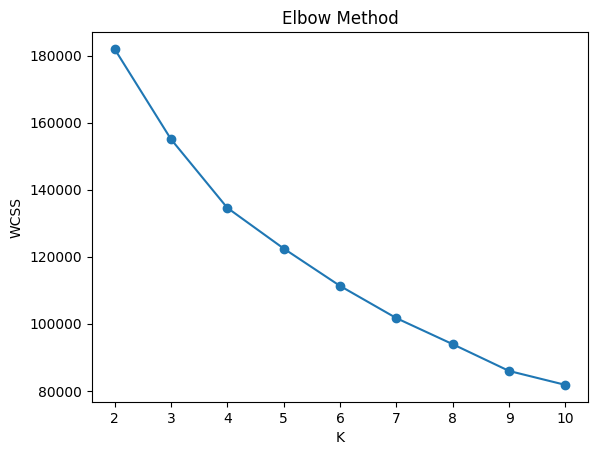

In [9]:
#Elbow Method:
wcss = []

for k in range(2,11):

    model = KMeans(n_clusters=k,random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.plot(range(2,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
# Final KMeans:
# (Assume K = 3)
kmeans = KMeans(n_clusters=3,random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z,Cluster
0,0,0.23,4.0,5.0,1.0,61.50,55.0,5.789960,3.95,3.98,2.43,2
1,1,0.21,3.0,5.0,2.0,59.80,61.0,5.789960,3.89,3.84,2.31,2
2,2,0.23,1.0,5.0,4.0,58.75,63.5,5.793014,4.05,4.07,2.31,1
3,3,0.29,3.0,1.0,3.0,62.40,58.0,5.814131,4.20,4.23,2.63,2
4,4,0.31,1.0,0.0,1.0,63.30,58.0,5.817111,4.34,4.35,2.75,1
...,...,...,...,...,...,...,...,...,...,...,...,...
53770,53935,0.72,4.0,6.0,2.0,60.80,57.0,7.922261,5.75,5.76,3.50,2
53771,53936,0.72,1.0,6.0,2.0,63.10,55.0,7.922261,5.69,5.75,3.61,1
53772,53937,0.70,2.0,6.0,2.0,62.80,60.0,7.922261,5.66,5.68,3.56,1
53773,53938,0.86,3.0,2.0,1.0,61.00,58.0,7.922261,6.15,6.12,3.74,0


In [ ]:
# Silhouette Score:
score = silhouette_score(X_scaled,df['Cluster'])
print(f"Silhouette Score: {round(score,4)}")

Silhouette Score: 0.244


In [13]:
# Cluster Profiling:
cluster_profile = df.groupby('Cluster').agg({'price':'mean','carat':'mean','cut':'mean','color':'mean','clarity':'mean'}).round(2)
print(cluster_profile)

# Cluster Names:
cluster_names = {0:'Premium Heavy Diamonds',1:'Affordable Small Diamonds',2:'Mid-range Balanced Diamonds'}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

print(df[['Cluster','Cluster_Name']].head())

         price  carat   cut  color  clarity
Cluster                                    
0         8.89   1.31  3.07   2.56     2.55
1         7.71   0.73  1.66   4.02     2.24
2         6.99   0.43  3.51   3.69     3.92
   Cluster                 Cluster_Name
0        2  Mid-range Balanced Diamonds
1        2  Mid-range Balanced Diamonds
2        1    Affordable Small Diamonds
3        2  Mid-range Balanced Diamonds
4        1    Affordable Small Diamonds


In [14]:
df

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z,Cluster,Cluster_Name
0,0,0.23,4.0,5.0,1.0,61.50,55.0,5.789960,3.95,3.98,2.43,2,Mid-range Balanced Diamonds
1,1,0.21,3.0,5.0,2.0,59.80,61.0,5.789960,3.89,3.84,2.31,2,Mid-range Balanced Diamonds
2,2,0.23,1.0,5.0,4.0,58.75,63.5,5.793014,4.05,4.07,2.31,1,Affordable Small Diamonds
3,3,0.29,3.0,1.0,3.0,62.40,58.0,5.814131,4.20,4.23,2.63,2,Mid-range Balanced Diamonds
4,4,0.31,1.0,0.0,1.0,63.30,58.0,5.817111,4.34,4.35,2.75,1,Affordable Small Diamonds
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53770,53935,0.72,4.0,6.0,2.0,60.80,57.0,7.922261,5.75,5.76,3.50,2,Mid-range Balanced Diamonds
53771,53936,0.72,1.0,6.0,2.0,63.10,55.0,7.922261,5.69,5.75,3.61,1,Affordable Small Diamonds
53772,53937,0.70,2.0,6.0,2.0,62.80,60.0,7.922261,5.66,5.68,3.56,1,Affordable Small Diamonds
53773,53938,0.86,3.0,2.0,1.0,61.00,58.0,7.922261,6.15,6.12,3.74,0,Premium Heavy Diamonds


In [16]:
#Saving Model:
joblib.dump(kmeans,"diamond_clustering.pkl")


['diamond_clustering.pkl']

In [17]:
joblib.dump(scaler,"diamond_cluster_scaler.pkl")

['diamond_cluster_scaler.pkl']